# Quantitative Market Analysis Framework
## Statistical Characterization, Factor Modeling and Portfolio Construction

This project presents the development of a modular quantitative framework designed to analyze financial assets from three complementary perspectives:

1. **Statistical behavior of returns**
2. **Cross-asset relationships and factor exposure**
3. **Portfolio construction and allocation**

The objective is to simulate how a real client or investment analyst would interact with a quantitative analytics library.  
Instead of isolated scripts, the system is structured into reusable classes that encapsulate financial theory, statistical modeling, and portfolio mathematics.

---

## Framework Architecture

The framework is divided into three main modules:

### 1. `market_data`
Focuses on **data preparation and statistical characterization** of financial assets.

Main responsibilities:

- Load and clean financial time series
- Compute returns
- Visualize price evolution
- Estimate statistical properties
- Identify probabilistic behavior of returns

Key analytical capabilities:

- Time series normalization and synchronization
- Descriptive statistics
- Risk metrics computation
- Distribution fitting using **Tukey–Lambda transformation**
- Tail behavior analysis

---

### 2. `capm`
Implements **cross-asset dependency modeling** using linear factor models.

Main responsibilities:

- Synchronize asset and benchmark data
- Estimate linear relationships between assets
- Measure systematic risk exposure

Mathematical tools used:

- Ordinary Least Squares (OLS)
- Linear regression:
  
\[
R_i = \alpha + \beta R_m + \varepsilon
\]

Where:

- \( \beta \) measures systematic exposure
- \( \alpha \) captures abnormal return
- \( R^2 \) evaluates explanatory power
- Correlation measures co-movement strength

This module allows comparison between assets and identification of dominant market drivers.

---

### 3. `portfolio_class`
Implements portfolio construction techniques.

Main responsibilities:

- Covariance estimation
- Portfolio allocation
- Risk diversification
- Optimization-based allocation

Mathematical foundations:

- Covariance matrices
- Mean-variance optimization
- Markowitz portfolio theory
- Constrained optimization problems

---

## Statistical and Mathematical Foundations

The framework integrates several quantitative methodologies:

### Financial Time Series Analysis
- Log/relative returns
- Temporal alignment
- Volatility representation

### Distribution Modeling — Tukey Lambda
Instead of assuming normality, returns are fitted using the Tukey-Lambda family:

\[
Q(p,\lambda)=
\begin{cases}
\log\left(\frac{p}{1-p}\right), & \lambda = 0 \\
\frac{p^\lambda-(1-p)^\lambda}{\lambda}, & \lambda \neq 0
\end{cases}
\]

The optimal parameter \( \lambda \) is obtained via PPCC (Probability Plot Correlation Coefficient) optimization:

\[
\min (1 - PPCC)^2
\]

This allows classification of return distributions into theoretical families such as:

- Cauchy (heavy tails)
- Laplace
- Logistic
- Normal
- Uniform

---

### Linear Factor Modeling
Regression analysis estimates how much an asset reacts to benchmark movements through beta exposure.

---

### Portfolio Optimization
Portfolio weights are obtained under different allocation constraints:

- Long-only allocation
- Mean-variance optimization
- Risk diversification via covariance structure

---

## Design Philosophy

The framework is built under a **client-oriented perspective**:

- Analysts interact through high-level methods
- Mathematical complexity remains encapsulated
- New metrics or models can be added modularly
- The same workflow can be adapted to any structured financial dataset

The following notebook demonstrates how an end user would naturally explore assets using this framework.

## Analytical Workflow — User Perspective

This notebook follows the logical process an investment analyst would typically perform when evaluating financial assets.

The analysis is divided into independent stages, each corresponding to one module of the framework.

---

### Part 1 — Statistical Exploration of Assets (`market_data`)

Before constructing portfolios or studying market relationships, an analyst must understand the individual behavior of each asset.

Key questions addressed in this stage:

- How does the asset evolve through time?
- What are its main risk and performance metrics?
- Does the return distribution resemble a known probabilistic model?
- Are tail risks present?

The `market_data` module provides a structured interface to load time series, visualize prices, compute statistics, and estimate the probabilistic structure of returns.

The objective of this section is to transform raw price data into statistically interpretable information.

---

Subsequent sections will extend the analysis toward:

- Cross-asset relationships (CAPM modeling)
- Portfolio allocation and optimization

In [87]:
# ============================================================
# PART 1 — Statistical Analysis of Individual Assets
# Module: market_data
# ============================================================

import importlib
import market_data

importlib.reload(market_data)

<module 'market_data' from '/Users/hectorastudillo/py-proyects/Quant_Finance_Project/market_data.py'>

In [88]:
# Asset to analyze
ric = "KOFUBL"

# Create analysis object
asset = market_data.distribution_manager(ric)

## Loading the Time Series — Parameterized Date Selection

The first step in the analysis consists of loading the financial time series associated with the selected asset.

```python
asset.load_timeseries(from_date='aaaa-mm-dd', to_date='aaaa-mm-dd')
```

This method replaces the previous interactive date filtering approach with a **parameter-based design**, allowing the analyst to explicitly define the time interval directly in the function call.

This modification improves:

* Computational efficiency (no runtime prompts)
* Reproducibility of experiments
* Script automation
* Reduction of user input errors

---

## Conceptual Objective

The purpose of this method is to construct the empirical random variable used throughout the analysis.

Internally, the function:

* Loads the raw historical dataset using the standalone `load_timeseries()` function.
* Optionally filters observations according to the specified date interval.
* Extracts the return series.
* Stores the return vector as the statistical object analyzed later.

After execution, the attribute:

```
self.vector
```

represents the realized return distribution of the asset.

---

## Parameters

### `from_date`

Starting date of the analysis window.

Format:

```
'YYYY-MM-DD'
```

If provided, the dataset will include observations **from this date onward**.

---

### `to_date`

Ending date of the analysis window.

Format:

```
'YYYY-MM-DD'
```

If provided, the dataset will include observations **up to this date**.

---

## Available Usage Scenarios

The method supports flexible subsetting depending on which parameters are specified.

---

### 1. Full historical dataset (default behavior)

```python
asset.load_timeseries()
```

Both parameters remain at their default values, therefore:

* No filtering is applied
* The entire database history is loaded

This is useful for long-term statistical characterization.

---

### 2. Specific time interval

```python
asset.load_timeseries(
    from_date="2018-01-01",
    to_date="2022-12-31"
)
```

Only observations inside the selected window are loaded.

Typical use cases:

* Crisis analysis
* Market regime comparison
* Event-driven studies

---

### 3. Open-ended interval — starting date only

```python
asset.load_timeseries(from_date="2020-01-01")
```

Behavior:

* Data is loaded from the specified starting date
* The ending date automatically becomes the latest available observation in the database

This is useful when analyzing recent market dynamics.

---

### 4. Open-ended interval — ending date only

```python
asset.load_timeseries(to_date="2019-12-31")
```

Behavior:

* Data is loaded from the earliest available observation
* Stops at the specified ending date

Useful for historical backtesting or pre-event analysis.


In [89]:
# Load time series and compute returns
asset.load_timeseries()

Then we can get the statistical information selected and graph it.

<Figure size 640x480 with 0 Axes>

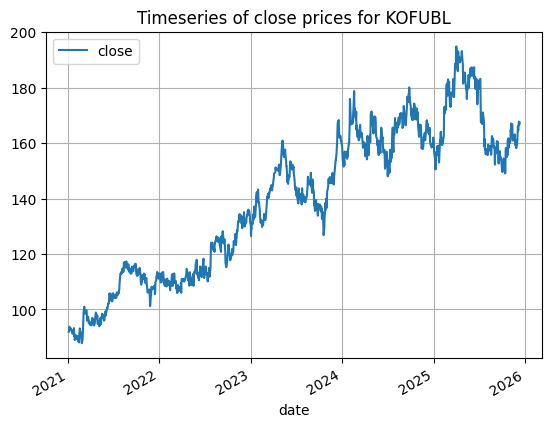

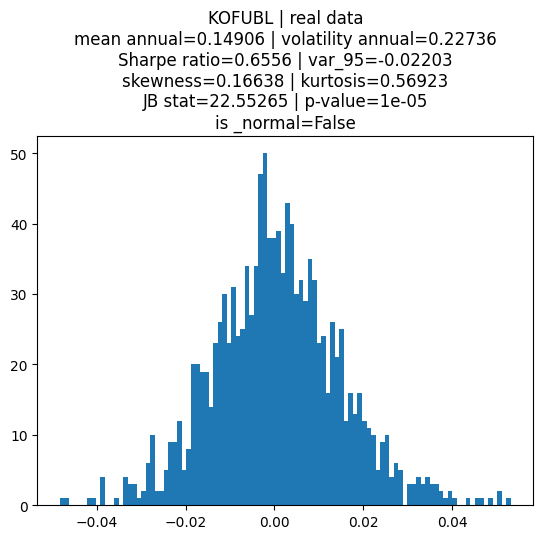

In [90]:
# Visualization of the time series
asset.plot_timeseries()

# Statistical characterization
asset.compute_stats()
asset.plot()

## Distribution Identification — Tukey Lambda Method

Financial returns rarely follow a perfect normal distribution.  
To avoid imposing a theoretical assumption, we estimate the distribution shape directly from the data.

asset.tukey_quantile(tolerance=0.05)

tolerance
Defines how close the estimated lambda must be to theoretical reference values in order to classify the distribution.
Smaller tolerance:
stricter classification
fewer matches
higher precision
Larger tolerance:
more permissive classification
broader grouping of assets

In [91]:
# Distribution identification (Tukey Lambda)
asset.tukey_quantile(tolerance=0.05)

KOFUBL  has the following data:
Optimal Lambda Obtained: 0.03478125000000014
PPCC obtained: 0.9991513779365976
Close to a  Logistic  distribution.


In [92]:
# Analysis for multiple assets (universe)
rics = ["KOFUBL", "BIMBOA", "BBVA"]

for r in rics:
    obj = market_data.distribution_manager(r)
    obj.load_timeseries()
    obj.compute_stats()
    obj.tukey_quantile()

KOFUBL  has the following data:
Optimal Lambda Obtained: 0.03478125000000014
PPCC obtained: 0.9991513779365976
Close to a  Logistic  distribution.
BIMBOA  has the following data:
Optimal Lambda Obtained: -0.07978515624999918
PPCC obtained: 0.9977891110278971
Close to a  Hyperbolic Secant  distribution.
BBVA  has the following data:
Optimal Lambda Obtained: -0.14071875
PPCC obtained: 0.9968804875383701
Close to a  Laplace  distribution.


# Universe-Level Distribution Analysis

So far, the analysis has focused on individual assets.  
However, quantitative research frequently requires understanding the statistical behavior of an entire market universe.

Two complementary diagnostics are introduced:

### 1. Tukey Lambda Classification

The function `get_all_lambda()` estimates the optimal Tukey–Lambda parameter for every asset stored in the database directory.

This allows us to classify assets according to their empirical distribution shape:

- Heavy-tailed assets (riskier extreme behavior)
- Near-normal assets
- Flat or uniform-like distributions

Instead of assuming normality, this procedure lets the data determine the probabilistic structure.

---

### 2. Higher Moments Analysis

Financial returns are known to deviate from Gaussian assumptions.

The function `get_all_kurtosis_skewness()` computes:

- Mean and median returns
- Kurtosis (tail thickness)
- Skewness (asymmetry)
- Sample size and observation window

These metrics help identify:

- Assets prone to extreme events (high kurtosis)
- Downside risk asymmetry (negative skewness)

Together, both analyses provide a distributional map of the market universe.

In [93]:
# ============================================================
# Universe-Level Statistical Analysis
# Functions from market_data module
# ============================================================

# Tukey Lambda estimation for entire universe
df_lambda = market_data.get_all_lambda(
    directory="market_universe",
    tolerance=0.03,
    printMetrics=False
)

df_lambda.head()

,ric,lambda,tipo
0,KOFUBL,0.034781,NaN
1,UVIX,-0.303375,NaN
2,GCARSOA1,-0.007617,Logistic
3,MSCI_EM,-0.133930,Laplace
4,TerraClassicUSD,-0.457125,NaN


In [94]:
# Kurtosis and Skewness analysis for all assets
df_moments = market_data.get_all_kurtosis_skewness(
    ric=ric,
    directory="market_universe"
)

df_moments.head()

,ric,%median,%mean,kurtosis,skewness,sample-size,from,up to
0,KOFUBL,0.024313,0.059149,0.569228,0.166380,1245,2021-01-05,2025-12-11
1,GCARSOA1,0.063028,0.075345,1.111499,0.278437,1239,2021-01-05,2025-12-03
2,KIMBERA,0.000000,0.023189,1.202233,0.172412,1245,2021-01-05,2025-12-11
3,GFINBURO,0.027300,0.078633,1.305442,0.314476,1245,2021-01-05,2025-12-11
4,USDEUR,0.010661,0.003726,1.578759,-0.211330,1289,2021-01-04,2025-12-11


# CAPM Model — Correlation, Beta and Linear Regression Framework

This module introduces the **model class**, designed to study the statistical relationship between two financial assets through linear regression.

The objective is to quantify:

- Linear dependence between assets
- Sensitivity (Beta) relative to a benchmark
- Explanatory power of one asset over another
- Statistical significance of the relationship

Conceptually, this class implements a practical interpretation of the **Capital Asset Pricing Model (CAPM)** using empirical return distributions.

---

## General Workflow

A typical analysis follows this structure:

```python
security = "AMZN"
benchmark = "^SPX"

analysis = capm.model(security, benchmark)

analysis.synchronise_timeseries()
analysis.compute_linear_reg()
analysis.plot_linear_reg()
```

---

## Class Initialization

### `model(security, benchmark, decimals=5)`

### Parameters

**security**  
Asset whose behavior we want to explain.

**benchmark**  
Reference asset used as explanatory variable.  
Economically, the benchmark explains the security.

**decimals**  
Number of decimals used when storing regression results.

---

## Conceptual Interpretation

The regression estimated is:

\[
R_{security} = \alpha + \beta R_{benchmark} + \epsilon
\]

where:

- **β (beta)** measures sensitivity to the benchmark.
- **α (alpha)** measures abnormal return not explained by the benchmark.

---

## Method: `synchronise_timeseries()`

```python
analysis.synchronise_timeseries(extremeValues=False)
```

### Objective
Financial assets rarely share identical trading calendars.  
This method aligns both datasets by matching dates so regression is computed only on comparable observations.

### Parameters

**extremeValues : bool**

- If True, allows preprocessing rules defined inside market_data.
- If False, raw synchronized returns are used.

### Output

Creates internally:

`self.timeseries`

containing:

- aligned dates
- close prices
- synchronized returns

---

## Method: `plot_timeseries()`

```python
analysis.plot_timeseries()
```

### Objective
Visual comparison of both assets' price evolution.

### Description

- Benchmark plotted on primary axis.
- Security plotted on secondary axis.

Useful for detecting structural co-movements before statistical modeling.

### Typical Use Cases

- Regime comparison
- Divergence detection
- Structural breaks

---

## Method: `compute_linear_reg()`

```python
analysis.compute_linear_reg()
```

### Objective
Estimate the linear regression between benchmark and security returns.

### Internal Procedure

Extract synchronized returns:

- `return_x` → benchmark
- `return_y` → security

Apply:

`scipy.stats.linregress()`

Store statistical metrics.

### Stored Outputs

- `self.beta` → slope coefficient
- `self.alpha` → intercept
- `self.correlation` → Pearson correlation
- `self.r_squared` → explanatory power
- `self.p_value` → hypothesis test significance
- `self.predictor_linreg` → fitted regression line

### Interpretation

- High beta → strong sensitivity to benchmark
- High R² → benchmark explains large portion of variance
- Low p-value → statistically meaningful relationship

---

## Method: `plot_linear_reg()`

```python
analysis.plot_linear_reg()
```

### Objective
Visualize the regression structure.

### Description

Produces:

- Scatterplot of returns
- Estimated regression line
- Statistical summary in title

### Analytical Value

Allows visual validation of:

- Linearity assumption
- Outliers
- Volatility clustering

---

## Method: `get_all_correlations()`

```python
analysis.get_all_correlations(getCSV=False, filter_dates=False)
```

### Objective

Compute correlations and betas between a benchmark and the entire asset universe.

This automates an otherwise \( O(n^2) \) manual comparison process.

### Parameters

**getCSV : bool**

If True, exports results into a CSV file.

**filter_dates : bool**

If True, user specifies a time interval.  
Enables regime-specific correlation analysis.

---

## Conceptual Warning

Correlation direction matters:

A benchmark explains an asset.  
An index does not necessarily explain individual securities symmetrically.

Example:

- BIMBOA explains MXX
- MXX does not necessarily explain BIMBOA

---

## Output

Creates:

`self.allCorrelationsDf`

containing:

- benchmark
- correlation
- beta
- r²
- compared security

Sorted by highest correlation.

In [95]:
import capm
importlib.reload(capm)

<module 'capm' from '/Users/hectorastudillo/py-proyects/Quant_Finance_Project/capm.py'>

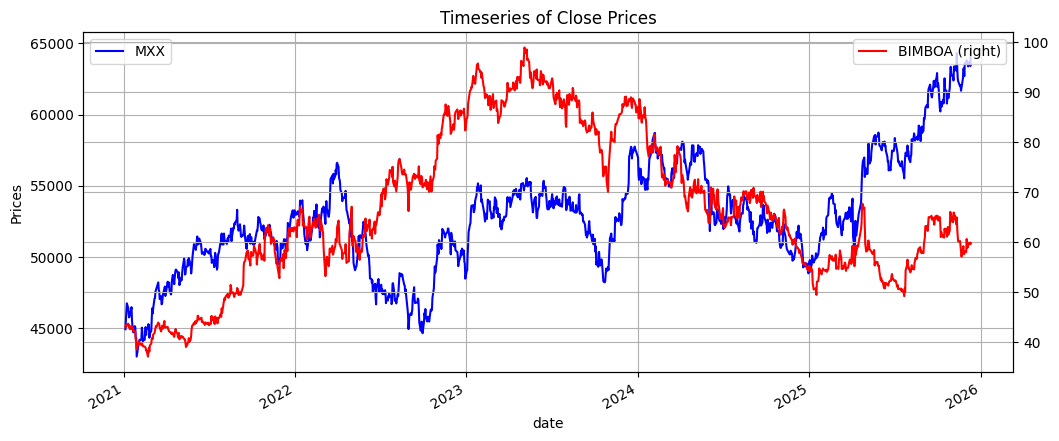

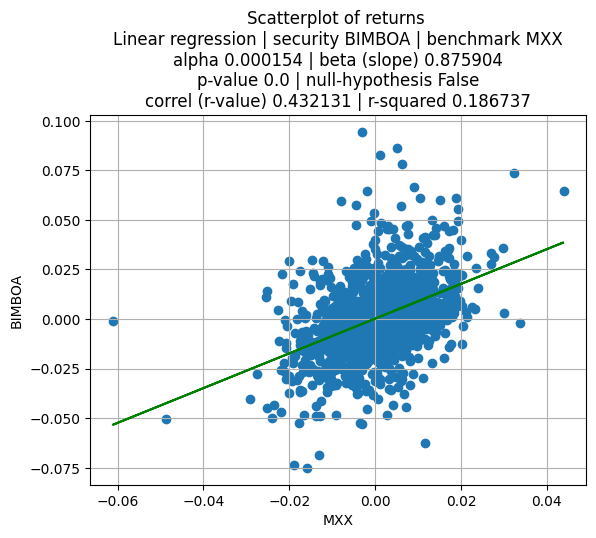

In [96]:
security = "BIMBOA"
benchmark = "MXX"

summary = capm.model(security, benchmark, 6)

summary.synchronise_timeseries(extremeValues=False)
summary.plot_timeseries()

summary.compute_linear_reg()
summary.plot_linear_reg()

# Method Documentation — `get_all_correlations()`

## Objective

The method `get_all_correlations()` is designed to **systematically compute the statistical relationship between a benchmark and an entire universe of assets**.

Instead of manually comparing assets one by one, this method automates the process and builds a structured dataset containing:

- Correlation
- Beta
- Explanatory power (R²)
- Effective observation window (dates used in the regression)

This allows fast identification of assets that behave similarly to a benchmark and supports portfolio construction, hedging analysis, and factor discovery.

---

## Conceptual Motivation

In financial analysis, it is common to ask:

> *Which assets move similarly to my benchmark?*

Examples:

- Finding substitutes or hedging candidates
- Detecting sector exposure
- Understanding systemic risk transmission
- Studying regime dependence across markets

!!!! **Important conceptual note**

Correlation direction matters:

- A benchmark explains an asset.
- An index does not necessarily explain individual securities symmetrically.

Example:

- BIMBOA may explain movements in MXX.
- MXX does not necessarily explain BIMBOA.

---

## Method Definition

```python
get_all_correlations(getCSV=False,
                     from_date='aaaa-mm-dd',
                     to_date='aaaa-mm-dd')
```

---

## Parameters

### `getCSV : bool`
Default: `False`

If set to `True`, the resulting dataframe is exported into a CSV file.

Purpose:
- External analysis
- Reporting
- Further manipulation outside Python (Excel, SQL, BI tools)

After exporting, the method prints a confirmation message indicating that the file was updated and can be renamed if needed.

---

### `from_date : str`
Default: `'aaaa-mm-dd'`

Defines the **starting date** used for the regression analysis.

If provided:
- Only observations **greater or equal** to this date are used.

If not provided:
- The method automatically uses the earliest available date in the dataset.

---

### `to_date : str`
Default: `'aaaa-mm-dd'`

Defines the **ending date** used for the regression analysis.

If provided:
- Only observations **less or equal** to this date are used.

If not provided:
- The method uses the latest available date in the dataset.

---

## Date Filtering Logic

The method supports three scenarios:

### 1. Full interval specified

```python
analysis.get_all_correlations(
    from_date='2022-02-12',
    to_date='2023-02-12'
)
```

Only data inside this window is used.

---

### 2. Only starting date specified

```python
analysis.get_all_correlations(
    from_date='2020-01-01'
)
```

Data is loaded from the chosen date until the **most recent available observation**.

---

### 3. Only ending date specified

```python
analysis.get_all_correlations(
    to_date='2021-12-31'
)
```

Data is loaded from the **earliest available observation** until the chosen date.

---

### 4. No dates specified

```python
analysis.get_all_correlations()
```

The full historical dataset is used.

---

## Internal Workflow

1. Obtain all asset names from the market universe.
2. Synchronize each asset with the benchmark.
3. Apply optional date filtering.
4. Compute linear regression statistics.
5. Store results into a structured dataframe.
6. Sort assets by highest correlation.
7. Optionally export results to CSV.

---

## Output DataFrame Structure

The resulting dataframe (`self.allCorrelationsDf`) contains:

| Column | Description |
|------|-------------|
| `benchmark` | Reference asset used as explanatory variable |
| `correlation` | Pearson correlation between returns |
| `beta` | Sensitivity of the asset relative to benchmark |
| `r2` | Coefficient of determination (explained variance) |
| `security` | Asset being compared |
| `min_date` | First observation used in regression |
| `max_date` | Last observation used in regression |

---

## Why `min_date` and `max_date` Matter

Not all assets share the same trading history.

Some securities:

- were recently listed,
- have missing historical data,
- or began trading later than others.

These columns show the **effective time window** actually used in the statistical estimation, improving transparency and auditability of results.

---

## CSV Export Behavior

If `getCSV=True`, the method creates or updates:

```
correlation_output.csv
```

A confirmation message is displayed:

> *The file was updated. If you want a new file, change `self.namefile` and a new file will be created automatically.*

This allows versioning different studies without modifying the core logic.

---

## Practical Use Cases

- Building hedge candidate universes
- Factor exposure discovery
- Portfolio similarity analysis
- Risk clustering
- Market regime comparison
- Quantitative research preprocessing

---

## Example Usage

```python
analysis = capm.model("GCARSOA1", "MXX")

analysis.synchronise_timeseries()

analysis.get_all_correlations(
    getCSV=True,
    from_date="2022-02-12",
    to_date="2023-02-12"
)

analysis.allCorrelationsDf.head()
```

---

## Final Interpretation

This method transforms a potentially manual and quadratic comparison process into a reproducible quantitative workflow, enabling scalable cross-asset statistical analysis aligned with CAPM intuition.

In [99]:
summary.get_all_correlations(from_date='2022-02-12', to_date='2023-02-12')
summary.allCorrelationsDf

,benchmark,correlation,beta,r2,security,min_date,max_date
0,MXX,1.00000,1.00000,1.00000,MXX,2022-02-14,2023-02-10
1,MXX,0.66100,1.62574,0.43692,CEMEXCPO,2022-02-14,2023-02-10
2,MXX,0.61106,0.99892,0.37340,ASURB,2022-02-14,2023-02-10
3,MXX,0.58714,1.21796,0.34474,GFNORTEO,2022-02-14,2023-02-10
4,MXX,0.58683,1.62706,0.34437,GMEXICOB,2022-02-14,2023-02-10
5,MXX,0.56959,0.70049,0.32443,MSCI_W,2022-02-14,2023-02-10
6,MXX,0.56159,1.22289,0.31538,GFINBURO,2022-02-14,2023-02-10
7,MXX,0.55204,0.66734,0.30475,IWD,2022-02-14,2023-02-10
8,MXX,0.54937,0.82460,0.30181,QUAL,2022-02-14,2023-02-10
9,MXX,0.54529,0.76960,0.29734,SPX,2022-02-14,2023-02-10
